In [118]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [119]:
import tensorflow
from tensorflow.keras.layers import Conv2D, UpSampling2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from keras.preprocessing.image import img_to_array

In [120]:


img_gray_scale=cv2.imread('/content/monalisa.jpg', 0)
img_BRG=cv2.imread('/content/monalisa.jpg', 1)

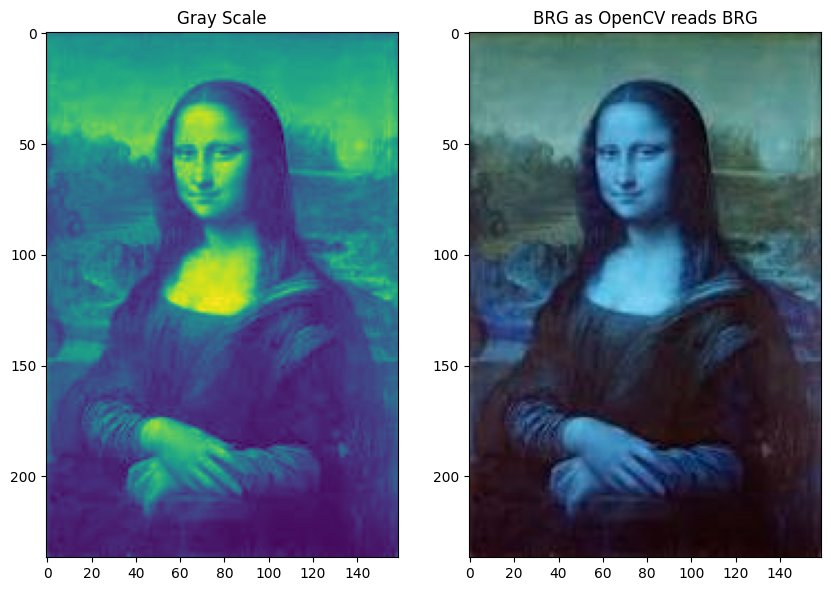

In [121]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(img_gray_scale)
axs[0].set_title('Gray Scale')
axs[1].imshow(img_BRG)
axs[1].set_title('BRG as OpenCV reads BRG')
plt.show()

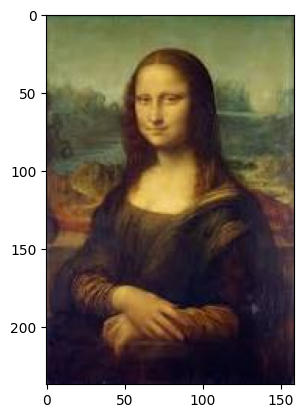

Original Image Shape is:  (237, 159, 3)
Resized Image Shape is:  (256, 256, 3)


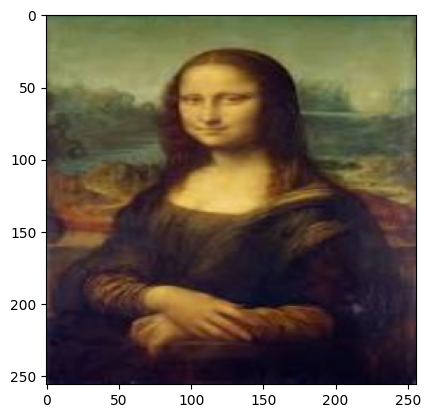

In [122]:
# Converting BRG to RGB
img=cv2.cvtColor(img_BRG, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()
print("Original Image Shape is: ", img.shape)
# so we have to resize it as well
img=cv2.resize(img, (256, 256))
plt.imshow(img)
print("Resized Image Shape is: ", img.shape)


In [123]:
img_data=[]

img_data.append(img_to_array(img))

In [124]:
len(img_data[0][0])
img_data=np.reshape(img_data, (len(img_data), 256, 256, 3))
img_data.shape

(1, 256, 256, 3)

In [125]:
# Normalising image data
img_data=img_data.astype('float')/255.

In [126]:
Size=256

model=Sequential()

# Encoder part
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(Size, Size, 3)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))

model.add(MaxPooling2D((2, 2), padding='same'))

model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(3, (3, 3), activation='relu', padding='same')) # Changed activation to sigmoid

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 128, 128, 8)    │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 64, 64, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_30 (UpSampling2D) │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 64, 64, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_31 (UpSampling2D) │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 128, 128, 32)   │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_32 (UpSampling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,163 (31.89 KB)

 Trainable params: 8,163 (31.89 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

In [128]:
model.fit(img_data, img_data, epochs=500, shuffle=True)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2255 - loss: 0.1106
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.2127 - loss: 0.1066
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.3601 - loss: 0.1012
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5083 - loss: 0.0946
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5297 - loss: 0.0865
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5354 - loss: 0.0772
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5361 - loss: 0.0667
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5361 - loss: 0.0564
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.5361 - loss: 0.0498
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5361 - loss: 0.0534
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5361 - loss: 0.0592
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


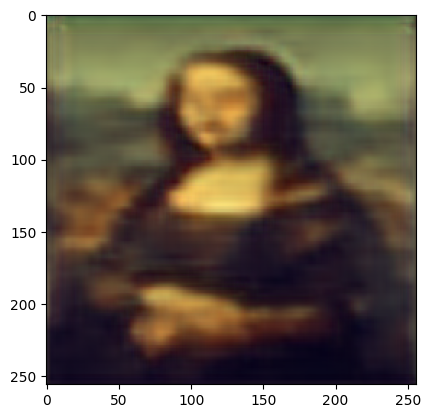

In [129]:
pred=model.predict(img_data)
plt.imshow(pred[0].reshape(256, 256, 3))
plt.show()